In [20]:
##1.Upload and load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()          # pick your data.csv in the popup
fname = list(uploaded.keys())[0]   # takes the uploaded file's name automatically
df = pd.read_csv(fname)
df

Saving data.csv to data (3).csv


,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0
5,60,'2020/12/06',102,127,300.0
6,60,'2020/12/07',110,136,374.0
7,450,'2020/12/08',104,134,253.3
8,30,'2020/12/09',109,133,195.1
9,60,'2020/12/10',98,124,269.0


In [21]:
##2.Inspect
print(df.shape)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df.describe()

(32, 5)
Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64
Duplicates: 1


,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,68.437500,103.500000,128.500000,304.680000
std,70.039591,7.832933,12.998759,66.003779
min,30.000000,90.000000,101.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,127.500000,291.200000
75%,60.000000,106.500000,132.250000,343.975000
max,450.000000,130.000000,175.000000,479.000000


In [22]:
##3.Fix the Date column
digits = df['Date'].astype(str).str.replace(r"[^0-9]", "", regex=True).str[:8]
df['Date'] = pd.to_datetime(digits, format='%Y%m%d', errors='coerce')
df = df.dropna(subset=['Date'])

print("Missing dates left:", df['Date'].isnull().sum())
print("Rows now:", len(df))
df['Date'].head()

Missing dates left: 0
Rows now: 31


,Date
0,2020-12-01
1,2020-12-02
2,2020-12-03
3,2020-12-04
4,2020-12-05


In [23]:
##4.Remove duplicates and fix wrong values
df = df.drop_duplicates().reset_index(drop=True)

# Duration typo: 450 -> 45
df.loc[df['Duration'] > 200, 'Duration'] = df['Duration'] / 10

# Pulse and Maxpulse entered the wrong way round: swap them
bad = df['Pulse'] > df['Maxpulse']
df.loc[bad, ['Pulse', 'Maxpulse']] = df.loc[bad, ['Maxpulse', 'Pulse']].values

df['Duration'] = df['Duration'].astype(int)
print("Duplicates left:", df.duplicated().sum())
print("Max Duration:", df['Duration'].max())
print("Rows where Pulse > Maxpulse:", (df['Pulse'] > df['Maxpulse']).sum())
print("Rows now:", len(df))

Duplicates left: 0
Max Duration: 60
Rows where Pulse > Maxpulse: 0
Rows now: 30


In [24]:
##5.Handle missing values
df['Calories'] = df['Calories'].fillna(df['Calories'].mean().round(1))
print(df.isnull().sum())

Duration    0
Date        0
Pulse       0
Maxpulse    0
Calories    0
dtype: int64


In [25]:
##6.Create new columns
df['Calories_per_min'] = (df['Calories'] / df['Duration']).round(2)
df['Pulse_range'] = df['Maxpulse'] - df['Pulse']
df['Weekday'] = df['Date'].dt.day_name()
df['Intensity'] = pd.cut(df['Calories_per_min'],
                         bins=[0, 5, 7, 100],
                         labels=['Low', 'Medium', 'High'])
df.head()

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_min,Pulse_range,Weekday,Intensity
0,60,2020-12-01,110,130,409.1,6.82,20,Tuesday,Medium
1,60,2020-12-02,117,145,479.0,7.98,28,Wednesday,High
2,60,2020-12-03,103,135,340.0,5.67,32,Thursday,Medium
3,45,2020-12-04,109,175,282.4,6.28,66,Friday,Medium
4,45,2020-12-05,117,148,406.0,9.02,31,Saturday,High


In [26]:
##7.Filter rows
high_cal = df[df['Calories'] > 300]
print(len(high_cal), "high-calorie sessions")
high_cal

14 high-calorie sessions


,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_min,Pulse_range,Weekday,Intensity
0,60,2020-12-01,110,130,409.1,6.82,20,Tuesday,Medium
1,60,2020-12-02,117,145,479.0,7.98,28,Wednesday,High
2,60,2020-12-03,103,135,340.0,5.67,32,Thursday,Medium
4,45,2020-12-05,117,148,406.0,9.02,31,Saturday,High
6,60,2020-12-07,110,136,374.0,6.23,26,Monday,Medium
10,60,2020-12-11,103,147,329.3,5.49,44,Friday,Medium
12,60,2020-12-13,106,128,345.3,5.76,22,Sunday,Medium
13,60,2020-12-14,104,132,379.3,6.32,28,Monday,Medium
17,45,2020-12-18,90,112,307.4,6.83,22,Friday,Medium
18,60,2020-12-19,103,123,323.0,5.38,20,Saturday,Medium


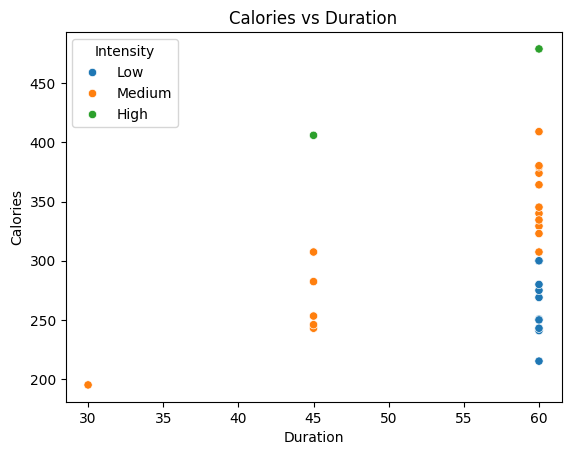

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
##8.Chart (the Matplotlib and Seaborn topic) and save
sns.scatterplot(data=df, x='Duration', y='Calories', hue='Intensity')
plt.title('Calories vs Duration')
plt.show()

df.to_csv('cleaned_data.csv', index=False)
files.download('cleaned_data.csv')